# Dependencies

In [125]:
# Standard libraries
import os
import joblib

# Data handling and visualization
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tabulate import tabulate

# Scikit-learn utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin

# Machine learning models
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
import xgboost as xgb
from xgboost import XGBClassifier, plot_importance

# Metrics and evaluation
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, recall_score, precision_score,
    f1_score, fbeta_score, classification_report, confusion_matrix
)

# Resampling techniques
from imblearn.over_sampling import SMOTE

# Pandas display settings
pd.set_option('display.max_columns', 200)

# Load

In [72]:
# app_df = pd.read_csv("https://raw.githubusercontent.com/arawsardni/5---Gaung-Taqwa-Indraswara---Sandra-Triana-Nursyafri/refs/heads/main/Dataset/raw/application_record.csv")
# cred_df = pd.read_csv("https://raw.githubusercontent.com/arawsardni/5---Gaung-Taqwa-Indraswara---Sandra-Triana-Nursyafri/refs/heads/main/Dataset/raw/credit_record.csv")

app_df = pd.read_csv("D:\File Gaung\Kuliah TIF UB\BCC\Intern 2025\Project\Dataset\\raw\\application_record.csv")
cred_df = pd.read_csv("D:\File Gaung\Kuliah TIF UB\BCC\Intern 2025\Project\Dataset\\raw\\credit_record.csv")

<>:4: SyntaxWarning: invalid escape sequence '\F'
<>:5: SyntaxWarning: invalid escape sequence '\F'
<>:4: SyntaxWarning: invalid escape sequence '\F'
<>:5: SyntaxWarning: invalid escape sequence '\F'
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_16404\2001248650.py:4: SyntaxWarning: invalid escape sequence '\F'
  app_df = pd.read_csv("D:\File Gaung\Kuliah TIF UB\BCC\Intern 2025\Project\Dataset\\raw\\application_record.csv")
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_16404\2001248650.py:5: SyntaxWarning: invalid escape sequence '\F'
  cred_df = pd.read_csv("D:\File Gaung\Kuliah TIF UB\BCC\Intern 2025\Project\Dataset\\raw\\credit_record.csv")


In [73]:
app_df.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


In [74]:
cred_df.head()

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


In [75]:
cred_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   ID              1048575 non-null  int64 
 1   MONTHS_BALANCE  1048575 non-null  int64 
 2   STATUS          1048575 non-null  object
dtypes: int64(2), object(1)
memory usage: 24.0+ MB


# Creating Target

In [76]:
is_bad = (
    cred_df['STATUS']
    .isin(['3','4','5'])
    .groupby(cred_df['ID'])
    .max()  # Jika ada minimal 1 True, return 1
    .astype(int)
)

# Aggregrating Credit Records

In [77]:
credit_agg = cred_df.groupby('ID').agg(
    CREDIT_HISTORY_LENGTH=('MONTHS_BALANCE', lambda x: abs(x.min() - x.max()) + 1)).reset_index()
    
# Gabungkan target dengan fitur agregasi kredit
credit_agg['IS_BAD'] = is_bad.values

In [78]:
cred_df['MONTHS_BALANCE'].describe()


count    1.048575e+06
mean    -1.913700e+01
std      1.402350e+01
min     -6.000000e+01
25%     -2.900000e+01
50%     -1.700000e+01
75%     -7.000000e+00
max      0.000000e+00
Name: MONTHS_BALANCE, dtype: float64

In [79]:
credit_agg

,ID,CREDIT_HISTORY_LENGTH,IS_BAD
0,5001711,4,0
1,5001712,19,0
2,5001713,22,0
3,5001714,15,0
4,5001715,60,0
...,...,...,...
45980,5150482,18,0
45981,5150483,18,0
45982,5150484,13,0
45983,5150485,2,0


# Merge Data

In [80]:
new_df = pd.merge(app_df, credit_agg, on="ID", how="inner")

In [136]:
test = new_df[new_df["IS_BAD"] == 1]
test

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,ANNUAL_INCOME,EMPLOYMENT_STATUS,EDUCATION_LEVEL,MARITAL_STATUS,DWELLING_TYPE,AGE,EMPLOYMENT_LENGTH,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,JOB_TITLE,CNT_FAM_MEMBERS,CREDIT_HISTORY_LENGTH,IS_BAD
652,5009628,F,N,N,0,238500.0,Working,Secondary / secondary special,Married,House / apartment,-19305,-3296,1,1,0,0,Laborers,2.0,60,1
1652,5010864,M,Y,Y,1,450000.0,Commercial associate,Secondary / secondary special,Married,House / apartment,-18173,-678,1,0,1,1,Core staff,3.0,52,1
1858,5018498,F,Y,Y,0,90000.0,Working,Secondary / secondary special,Married,House / apartment,-18950,-1002,1,1,1,0,Cooking staff,2.0,55,1
1860,5018501,F,Y,Y,0,90000.0,Working,Secondary / secondary special,Married,House / apartment,-18950,-1002,1,1,1,0,Cooking staff,2.0,35,1
1862,5018503,F,Y,Y,0,90000.0,Working,Secondary / secondary special,Married,House / apartment,-18950,-1002,1,1,1,0,Cooking staff,2.0,56,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36442,5148934,M,Y,N,0,108000.0,Working,Secondary / secondary special,Married,Office apartment,-17209,-1081,1,0,0,0,Security staff,2.0,22,1
36449,5149190,M,Y,N,1,450000.0,Working,Higher education,Married,House / apartment,-9847,-502,1,0,1,1,Core staff,3.0,12,1
36452,5149828,M,Y,Y,0,315000.0,Working,Secondary / secondary special,Married,House / apartment,-17348,-2420,1,0,0,0,Managers,2.0,12,1
36453,5149834,F,N,Y,0,157500.0,Commercial associate,Higher education,Married,House / apartment,-12387,-1325,1,0,1,1,Medicine staff,2.0,24,1


In [82]:
new_df.isna().sum()

ID                           0
CODE_GENDER                  0
FLAG_OWN_CAR                 0
FLAG_OWN_REALTY              0
CNT_CHILDREN                 0
AMT_INCOME_TOTAL             0
NAME_INCOME_TYPE             0
NAME_EDUCATION_TYPE          0
NAME_FAMILY_STATUS           0
NAME_HOUSING_TYPE            0
DAYS_BIRTH                   0
DAYS_EMPLOYED                0
FLAG_MOBIL                   0
FLAG_WORK_PHONE              0
FLAG_PHONE                   0
FLAG_EMAIL                   0
OCCUPATION_TYPE          11323
CNT_FAM_MEMBERS              0
CREDIT_HISTORY_LENGTH        0
IS_BAD                       0
dtype: int64

In [83]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     36457 non-null  int64  
 1   CODE_GENDER            36457 non-null  object 
 2   FLAG_OWN_CAR           36457 non-null  object 
 3   FLAG_OWN_REALTY        36457 non-null  object 
 4   CNT_CHILDREN           36457 non-null  int64  
 5   AMT_INCOME_TOTAL       36457 non-null  float64
 6   NAME_INCOME_TYPE       36457 non-null  object 
 7   NAME_EDUCATION_TYPE    36457 non-null  object 
 8   NAME_FAMILY_STATUS     36457 non-null  object 
 9   NAME_HOUSING_TYPE      36457 non-null  object 
 10  DAYS_BIRTH             36457 non-null  int64  
 11  DAYS_EMPLOYED          36457 non-null  int64  
 12  FLAG_MOBIL             36457 non-null  int64  
 13  FLAG_WORK_PHONE        36457 non-null  int64  
 14  FLAG_PHONE             36457 non-null  int64  
 15  FL

In [84]:
new_df = new_df.dropna()

In [85]:
new_df["IS_BAD"].value_counts(normalize=True)

IS_BAD
0    0.991923
1    0.008077
Name: proportion, dtype: float64

In [86]:
new_df["IS_BAD"].value_counts()

IS_BAD
0    24931
1      203
Name: count, dtype: int64

In [87]:
for column in new_df.select_dtypes(include='object'):
    unique_values = new_df[column].unique()
    print(f"Unique values in {column}: {unique_values}")

Unique values in CODE_GENDER: ['M' 'F']
Unique values in FLAG_OWN_CAR: ['Y' 'N']
Unique values in FLAG_OWN_REALTY: ['Y' 'N']
Unique values in NAME_INCOME_TYPE: ['Working' 'Commercial associate' 'State servant' 'Student' 'Pensioner']
Unique values in NAME_EDUCATION_TYPE: ['Secondary / secondary special' 'Higher education' 'Incomplete higher'
 'Lower secondary' 'Academic degree']
Unique values in NAME_FAMILY_STATUS: ['Married' 'Single / not married' 'Civil marriage' 'Separated' 'Widow']
Unique values in NAME_HOUSING_TYPE: ['House / apartment' 'Rented apartment' 'Municipal apartment'
 'With parents' 'Co-op apartment' 'Office apartment']
Unique values in OCCUPATION_TYPE: ['Security staff' 'Sales staff' 'Accountants' 'Laborers' 'Managers'
 'Drivers' 'Core staff' 'High skill tech staff' 'Cleaning staff'
 'Private service staff' 'Cooking staff' 'Low-skill Laborers'
 'Medicine staff' 'Secretaries' 'Waiters/barmen staff' 'HR staff'
 'Realty agents' 'IT staff']


# Renaming Feature

In [88]:
new_df = new_df.rename(columns={
    "DAYS_BIRTH" : "AGE",
    "NAME_FAMILY_STATUS" : "MARITAL_STATUS",
    "NAME_HOUSING_TYPE" :  "DWELLING_TYPE",
    "AMT_INCOME_TOTAL" : "ANNUAL_INCOME",
    "OCCUPATION_TYPE" : "JOB_TITLE",
    "NAME_EDUCATION_TYPE" : "EDUCATION_LEVEL",
    "DAYS_EMPLOYED" : "EMPLOYMENT_LENGTH",
    "NAME_INCOME_TYPE" : "EMPLOYMENT_STATUS"})

In [89]:
new_df

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,ANNUAL_INCOME,EMPLOYMENT_STATUS,EDUCATION_LEVEL,MARITAL_STATUS,DWELLING_TYPE,AGE,EMPLOYMENT_LENGTH,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,JOB_TITLE,CNT_FAM_MEMBERS,CREDIT_HISTORY_LENGTH,IS_BAD
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0,30,0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,5,0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,5,0
5,5008810,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,27,0
6,5008811,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,39,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36452,5149828,M,Y,Y,0,315000.0,Working,Secondary / secondary special,Married,House / apartment,-17348,-2420,1,0,0,0,Managers,2.0,12,1
36453,5149834,F,N,Y,0,157500.0,Commercial associate,Higher education,Married,House / apartment,-12387,-1325,1,0,1,1,Medicine staff,2.0,24,1
36454,5149838,F,N,Y,0,157500.0,Pensioner,Higher education,Married,House / apartment,-12387,-1325,1,0,1,1,Medicine staff,2.0,33,1
36455,5150049,F,N,Y,0,283500.0,Working,Secondary / secondary special,Married,House / apartment,-17958,-655,1,0,0,0,Sales staff,2.0,10,0


In [90]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25134 entries, 2 to 36456
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     25134 non-null  int64  
 1   CODE_GENDER            25134 non-null  object 
 2   FLAG_OWN_CAR           25134 non-null  object 
 3   FLAG_OWN_REALTY        25134 non-null  object 
 4   CNT_CHILDREN           25134 non-null  int64  
 5   ANNUAL_INCOME          25134 non-null  float64
 6   EMPLOYMENT_STATUS      25134 non-null  object 
 7   EDUCATION_LEVEL        25134 non-null  object 
 8   MARITAL_STATUS         25134 non-null  object 
 9   DWELLING_TYPE          25134 non-null  object 
 10  AGE                    25134 non-null  int64  
 11  EMPLOYMENT_LENGTH      25134 non-null  int64  
 12  FLAG_MOBIL             25134 non-null  int64  
 13  FLAG_WORK_PHONE        25134 non-null  int64  
 14  FLAG_PHONE             25134 non-null  int64  
 15  FLAG_EM

In [118]:
# Menampilkan semua baris dengan IS_BAD == 1
train_original[train_original["IS_BAD"] == 1]


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,ANNUAL_INCOME,EMPLOYMENT_STATUS,EDUCATION_LEVEL,MARITAL_STATUS,DWELLING_TYPE,AGE,EMPLOYMENT_LENGTH,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,JOB_TITLE,CNT_FAM_MEMBERS,CREDIT_HISTORY_LENGTH,IS_BAD
85,5118441,F,Y,N,1,108000.0,Commercial associate,Higher education,Married,House / apartment,-16138,-431,1,1,0,0,Sales staff,3.0,42,1
375,5126012,F,N,N,0,270000.0,State servant,Secondary / secondary special,Married,House / apartment,-20103,-1444,1,1,1,0,Waiters/barmen staff,2.0,32,1
411,5135345,M,N,Y,0,112500.0,Commercial associate,Higher education,Married,House / apartment,-20103,-555,1,0,0,0,Security staff,2.0,50,1
722,5078805,F,N,Y,0,306000.0,Working,Secondary / secondary special,Married,House / apartment,-18927,-2978,1,0,0,0,High skill tech staff,2.0,34,1
736,5091281,M,N,Y,0,202500.0,Working,Secondary / secondary special,Married,House / apartment,-13645,-5374,1,0,0,0,Laborers,2.0,11,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19578,5029451,F,Y,Y,0,225000.0,Working,Higher education,Married,House / apartment,-17402,-3153,1,0,1,0,Core staff,2.0,53,1
19591,5115604,F,N,Y,0,202500.0,Working,Secondary / secondary special,Married,House / apartment,-14523,-3420,1,0,0,0,Core staff,2.0,5,1
19608,5146167,F,N,Y,0,135000.0,Working,Secondary / secondary special,Married,House / apartment,-20296,-1770,1,0,0,0,Security staff,2.0,21,1
19720,5142973,M,N,N,1,180000.0,Working,Secondary / secondary special,Married,House / apartment,-10656,-926,1,1,1,0,Laborers,1.0,19,1


In [92]:
# split the data into train and test
def data_split(df, test_size):
    train_df, test_df = train_test_split(df, test_size=test_size, random_state=42)
    return train_df.reset_index(drop=True), test_df.reset_index(drop=True)

In [93]:
train_original, test_original = data_split(new_df, 0.2)

In [94]:
train_original["IS_BAD"].value_counts(normalize=True)

IS_BAD
0    0.991893
1    0.008107
Name: proportion, dtype: float64

In [95]:
test_original["IS_BAD"].value_counts(normalize=True)

IS_BAD
0    0.992043
1    0.007957
Name: proportion, dtype: float64

In [96]:
encoded_df = new_df.copy()
label_encoder = LabelEncoder()
for col in encoded_df.select_dtypes(include=['object']).columns:
    encoded_df[col] = label_encoder.fit_transform(encoded_df[col])

encoded_df

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,ANNUAL_INCOME,EMPLOYMENT_STATUS,EDUCATION_LEVEL,MARITAL_STATUS,DWELLING_TYPE,AGE,EMPLOYMENT_LENGTH,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,JOB_TITLE,CNT_FAM_MEMBERS,CREDIT_HISTORY_LENGTH,IS_BAD
2,5008806,1,1,1,0,112500.0,4,4,1,1,-21474,-1134,1,0,0,0,16,2.0,30,0
3,5008808,0,0,1,0,270000.0,0,4,3,1,-19110,-3051,1,0,1,1,14,1.0,5,0
4,5008809,0,0,1,0,270000.0,0,4,3,1,-19110,-3051,1,0,1,1,14,1.0,5,0
5,5008810,0,0,1,0,270000.0,0,4,3,1,-19110,-3051,1,0,1,1,14,1.0,27,0
6,5008811,0,0,1,0,270000.0,0,4,3,1,-19110,-3051,1,0,1,1,14,1.0,39,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36452,5149828,1,1,1,0,315000.0,4,4,1,1,-17348,-2420,1,0,0,0,10,2.0,12,1
36453,5149834,0,0,1,0,157500.0,0,1,1,1,-12387,-1325,1,0,1,1,11,2.0,24,1
36454,5149838,0,0,1,0,157500.0,1,1,1,1,-12387,-1325,1,0,1,1,11,2.0,33,1
36455,5150049,0,0,1,0,283500.0,4,4,1,1,-17958,-655,1,0,0,0,14,2.0,10,0


# List of Feature Preprocessing

ID:
* Drop the feature

CODE_GENDER: 
* One hot encoding

AGE from DAYS_BIRTH: 
* Min-max scaling
* Fix skewness
* Abs value and div 365.25

MARITAL_STATUS from NAME_FAMILY_STATUS: 
* One hot encoding

CNT_FAM_MEMBERS:
* Fix outliers

CNT_CHILDERN:
* Fix outliers
* Drop feature

DWELLING_TYPE from NAME_HOUSING_TYPE 
* One hot encoding

ANNUAL_INCOME from AMT_INCOME_TOTAL:
* Remove outliers
* Fix skewness
* Min-max scaling

JOB_TITLE from OCCUPATION_TYPE 
* One hot encoding


EMPLOYMENT_STATUS from NAME_INCOME_TYPE: 
* One hot encoding

EDUCATION_LEVEL from NAME_EDUCATION TYPE: 
* Ordinal encoding

EMPLOYMENT_LENGTH from DAYS_EMPLOYED: 
* Remove outliers
* Min-max scaling
* Abs value and div 365.25
* change days of employments of retirees to 0

FLAG_OWN_CAR: 
* Change it numerical
* One-hot encoding

FLAG_OWN_REALTY: 
* Change it numerical
* One-hot encoding

FLAG_MOBILE: 
* Drop feature (because all of it is 1) 

FLAG_WORK_PHONE : 
* One-hot encoding

FLAG_PHONE: 
* One-hot encoding

FLAG_EMAIL: 
* One-hot encoding

IS_BAD: 
* balance the data with Tomeklinks

# Preprocessing Data

In [102]:
# Improved column dropper
class DropColumns(BaseEstimator, TransformerMixin):
    def __init__(self, features):
        self.features = features

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X.drop(columns=[f for f in self.features if f in X.columns], errors='ignore')

In [103]:
# Improved time converter with configurable divisor
class TimeConverter(BaseEstimator, TransformerMixin):
    def __init__(self, features, divisor=365.25):
        self.features = features
        self.divisor = divisor

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_copy = X.copy()
        X_copy[self.features] = X_copy[self.features].abs() // self.divisor
        return X_copy

In [104]:
# Improved retiree handler
class HandleRetirees(BaseEstimator, TransformerMixin):
    def __init__(self, employment_length_col='EMPLOYMENT_LENGTH', retirement_value=365243):
        self.employment_length_col = employment_length_col
        self.retirement_value = retirement_value
        
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_copy = X.copy()
        X_copy.loc[X_copy[self.employment_length_col] == self.retirement_value, self.employment_length_col] = 0
        return X_copy

In [106]:
# Improved one-hot encoder
class OneHotEncoderTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, features, handle_unknown="ignore"):
        self.features = features
        self.encoder = OneHotEncoder(handle_unknown=handle_unknown, sparse_output=False)
        self.feature_names = None

    def fit(self, X, y=None):
        self.encoder.fit(X[self.features])
        self.feature_names = self.encoder.get_feature_names_out(self.features)
        return self

    def transform(self, X):
        encoded = self.encoder.transform(X[self.features])
        encoded_df = pd.DataFrame(encoded, 
                                columns=self.feature_names, 
                                index=X.index)
        return X.drop(columns=self.features).join(encoded_df)

In [107]:
# Improved ordinal encoder
class OrdinalEncoderTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, feature, mapping):
        self.feature = feature
        self.mapping = mapping
        self.default_value = -1  # Default value for unknown categories

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_copy = X.copy()
        X_copy[self.feature] = X_copy[self.feature].map(self.mapping).fillna(self.default_value)
        return X_copy

In [109]:
# Define features
numerical_features = ['AGE', 'ANNUAL_INCOME', 'EMPLOYMENT_LENGTH', 'CREDIT_HISTORY_LENGTH', 'CNT_FAM_MEMBERS']
categorical_features = ['MARITAL_STATUS', 'JOB_TITLE', 'EMPLOYMENT_STATUS', 'FLAG_WORK_PHONE', 'FLAG_OWN_REALTY', 'DWELLING_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR']
outlier_features = ['CNT_FAM_MEMBERS', 'ANNUAL_INCOME', 'EMPLOYMENT_LENGTH']

# Updated mapping for ordinal encoding
education_mapping = {
    'Lower secondary': 0, 
    'Secondary / secondary special': 1, 
    'Incomplete higher': 2,  
    'Higher education': 3, 
    'Academic degree': 4
}

# ML Algorithm

In [126]:
# Hyperparameter di hard code sesuai dengan eksperimen sebelumnya
# CatBoost Best hyperparameters  {'iterations': 700, 'depth': 5, 'learning_rate': 0.05864129169696527, 'l2_leaf_reg': 6, 'pos_weight': 7}
# LightGBM Best hyperparameters: {'n_estimators': 100, 'max_depth': 9, 'learning_rate': 0.14666220730432952, 'subsample': 0.745801901599822, 'colsample_bytree': 0.716382986210906, 'pos_weight': 9}
# XGBoost Best hyperparameters: {'n_estimators': 400, 'max_depth': 6, 'learning_rate': 0.060225553772344786, 'subsample': 0.8492602005172417, 'colsample_bytree': 0.642100489136356, 'scale_pos_weight': 7}

'''
Top 3 selected models:
  model_name  f2_score  recall  precision  balanced_accuracy  threshold
3   LightGBM  0.180941    0.75   0.044843           0.810933       0.05
4   CatBoost  0.128645    0.75   0.029821           0.777146       0.06
2    XGBoost  0.113809    0.75   0.025907           0.761906       0.02
'''

classifiers = {
    "CatBoost": CatBoostClassifier(
        iterations=700,
        depth=5,
        learning_rate=0.05864129169696527,
        l2_leaf_reg=6,
        class_weights=[1, 7],
        random_seed=42,
        thread_count=-1
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=100,  
        max_depth=9,  
        learning_rate=0.14666220730432952, 
        subsample=0.745801901599822,
        colsample_bytree=0.642100489136356,
        objective="binary",
        scale_pos_weight=9,
        random_state=42,
        num_threads=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=400,  
        max_depth=6,  
        learning_rate=0.060225553772344786,
        subsample=0.8492602005172417,
        colsample_bytree=0.7317879282909067,  
        scale_pos_weight=7,
        eval_metric="auc",  
        random_state=42, 
        n_jobs=-1
    ),
}


# Best Model

In [127]:
# Create a preprocessing pipeline without sampling
preprocessing_pipeline = Pipeline([
    ('drop_columns', DropColumns(features=['ID', 'FLAG_MOBIL', 'CNT_CHILDREN', 'FLAG_EMAIL', 'FLAG_PHONE'])),
    ('time_conversion', TimeConverter(features=['EMPLOYMENT_LENGTH', 'AGE'], divisor=365.25)),
    ('handle_retirees', HandleRetirees(employment_length_col='EMPLOYMENT_LENGTH', retirement_value=365243)),
    ('one_hot_encoding', OneHotEncoderTransformer(features=categorical_features, handle_unknown='ignore')),
    ('ordinal_encoding', OrdinalEncoderTransformer(feature='EDUCATION_LEVEL', mapping=education_mapping)),
])

In [128]:
def train_and_evaluate_models(X_train, X_test, y_train, y_test, manual_thresholds):
    """
    Train models and evaluate with manually specified thresholds for each model
    
    Parameters:
    -----------
    X_train : training features
    X_test : testing features
    y_train : training labels
    y_test : testing labels
    manual_thresholds : dictionary mapping model names to their optimal thresholds
    
    Returns:
    --------
    tuple : (trained_models, results, table)
    """
    results = []
    trained_models = {}

    for name, clf in classifiers.items():
        print(f"Training {name}...")
        clf.fit(X_train, y_train)
        
        # Use the manual threshold from Optuna
        threshold = manual_thresholds[name]
        
        # Get predictions using specified threshold
        y_proba = clf.predict_proba(X_test)[:, 1]
        y_pred = (y_proba >= threshold)
        
        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        f2 = fbeta_score(y_test, y_pred, beta=2)
        
        # Calculate confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        tn, fp, fn, tp = cm.ravel()
        
        # Calculate additional metrics
        specificity = tn / (tn + fp)  # True Negative Rate (TNR)
        balanced_accuracy = (recall + specificity) / 2  # Balanced Accuracy formula
        
        results.append([
            name, 
            threshold,
            accuracy, 
            balanced_accuracy,
            precision, 
            recall, 
            f1, 
            f2, 
            tp, 
            tn, 
            fp, 
            fn
        ])
        
        trained_models[name] = clf

    headers = ["Classifier", "Threshold", "Accuracy", "Balanced Accuracy", "Precision", "Recall", "F1 Score", "F2 Score", "TP", "TN", "FP", "FN"]
    table = tabulate(results, headers=headers, floatfmt=".4f")
    print("\nModel Evaluation Results:")
    print(table)
    
    return trained_models, results, table

In [129]:
def apply_resampling(X_train, y_train, method):
    if method == 'SMOTE':
        sampler = SMOTE(sampling_strategy=0.7, random_state=42)
    else:
        raise ValueError("Unknown resampling method")
    
    return sampler.fit_resample(X_train, y_train)

In [132]:
def main():
    # Define manual thresholds obtained from Optuna
    # Replace these values with your actual Optuna-optimized thresholds

    '''
    Top 3 selected models:
    model_name  f2_score  recall  precision  balanced_accuracy  threshold
    3   LightGBM  0.180941    0.75   0.044843           0.810933       0.05
    4   CatBoost  0.128645    0.75   0.029821           0.777146       0.06
    2    XGBoost  0.113809    0.75   0.025907           0.761906       0.02
    '''

    manual_thresholds = {
        'CatBoost': 0.06,  
        'LightGBM': 0.05,       
        'XGBoost': 0.02,   
    }
    
    
    # Step 2: Split features and target
    X_filtered, y_filtered = train_original.drop(columns=['IS_BAD']), train_original['IS_BAD']
    X_test, y_test = test_original.drop(columns=['IS_BAD']), test_original['IS_BAD']
    
    print(f"Training data shape after outlier removal: {X_filtered.shape}, {y_filtered.shape}")
    print(f"Class distribution after outlier removal: {y_filtered.value_counts(normalize=True)}")
    
    # Step 3: Apply preprocessing
    print("Applying preprocessing...")
    X_train_preprocessed = preprocessing_pipeline.fit_transform(X_filtered)
    X_test_preprocessed = preprocessing_pipeline.transform(X_test)
    
    # Step 4: Apply ADASYN resampling (since we already know it's the best method)
    print("Applying SMOTE resampling...")
    X_train_resampled, y_train_resampled = apply_resampling(X_train_preprocessed, y_filtered, 'SMOTE')
    
    print(f"Training data shape after preprocessing and resampling: {X_train_resampled.shape}")
    print(f"Class distribution after resampling: {np.bincount(y_train_resampled)}")
    
    # Step 5: Train and evaluate models with manual thresholds
    print("Training and evaluating models...")
    trained_models, results, table = train_and_evaluate_models(
        X_train_resampled, X_test_preprocessed, y_train_resampled, y_test, manual_thresholds
    )
    
    # Determine best model based on Balanced Accuracy
    best_model_idx = max(range(len(results)), key=lambda i: results[i][3])  # Index 3 is Balanced Accuracy
    best_model_name = results[best_model_idx][0]  # Index 0 is model name
    
    return trained_models, manual_thresholds, best_model_name, results, table

Training data shape after outlier removal: (20107, 19), (20107,)
Class distribution after outlier removal: IS_BAD
0    0.991893
1    0.008107
Name: proportion, dtype: float64
Applying preprocessing...
Applying SMOTE resampling...
Training data shape after preprocessing and resampling: (33904, 48)
Class distribution after resampling: [19944 13960]
Training and evaluating models...
Training CatBoost...


C:\Users\LENOVO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


0:	learn: 0.6474338	total: 34.5ms	remaining: 24.1s
1:	learn: 0.5960120	total: 46.5ms	remaining: 16.2s
2:	learn: 0.5263862	total: 58.9ms	remaining: 13.7s
3:	learn: 0.4935283	total: 70.6ms	remaining: 12.3s
4:	learn: 0.4387886	total: 79.6ms	remaining: 11.1s
5:	learn: 0.4157744	total: 91.5ms	remaining: 10.6s
6:	learn: 0.3789957	total: 103ms	remaining: 10.2s
7:	learn: 0.3628575	total: 111ms	remaining: 9.6s
8:	learn: 0.3515067	total: 123ms	remaining: 9.41s
9:	learn: 0.3345742	total: 134ms	remaining: 9.23s
10:	learn: 0.3235494	total: 143ms	remaining: 8.97s
11:	learn: 0.3143701	total: 155ms	remaining: 8.88s
12:	learn: 0.3050931	total: 165ms	remaining: 8.7s
13:	learn: 0.2853921	total: 175ms	remaining: 8.55s
14:	learn: 0.2779839	total: 186ms	remaining: 8.51s
15:	learn: 0.2717776	total: 195ms	remaining: 8.33s
16:	learn: 0.2651221	total: 206ms	remaining: 8.27s
17:	learn: 0.2600870	total: 217ms	remaining: 8.21s
18:	learn: 0.2541952	total: 226ms	remaining: 8.09s
19:	learn: 0.2498052	total: 237ms	rem

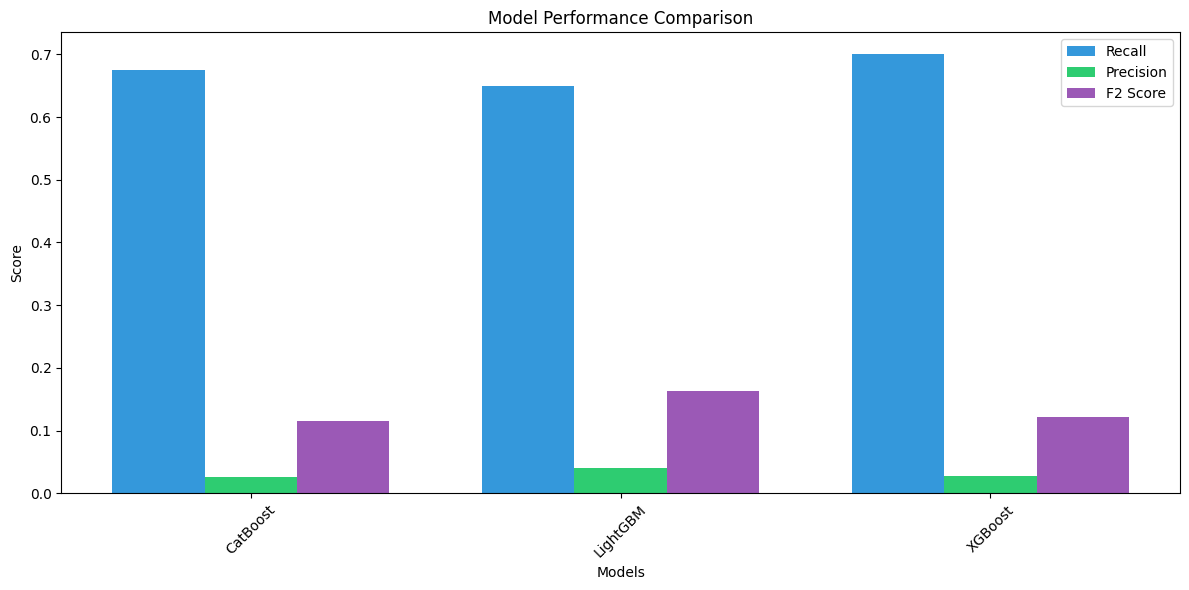

C:\Users\LENOVO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


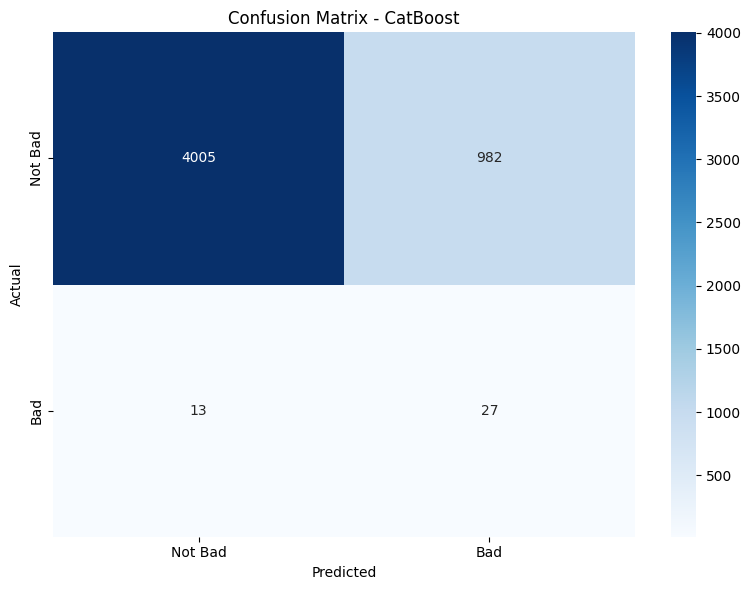


Classification Report for CatBoost Model:
              precision    recall  f1-score   support

           0       1.00      0.80      0.89      4987
           1       0.03      0.68      0.05        40

    accuracy                           0.80      5027
   macro avg       0.51      0.74      0.47      5027
weighted avg       0.99      0.80      0.88      5027



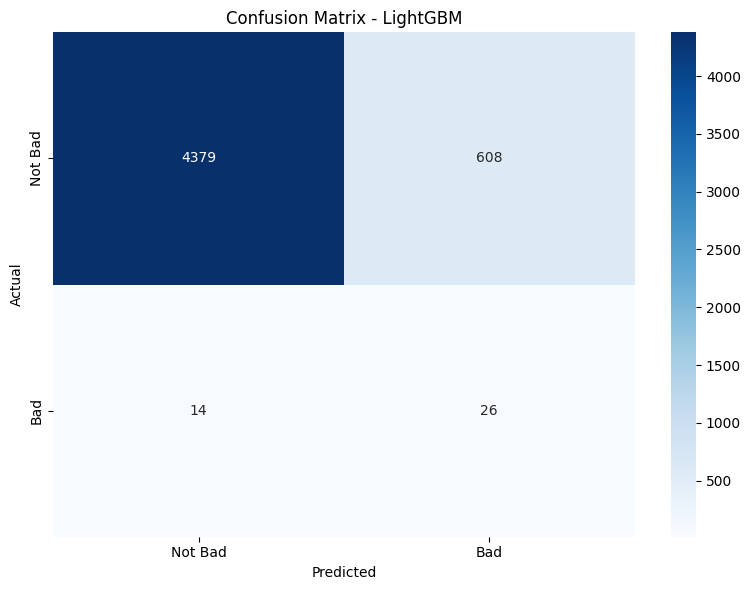


Classification Report for LightGBM Model:
              precision    recall  f1-score   support

           0       1.00      0.88      0.93      4987
           1       0.04      0.65      0.08        40

    accuracy                           0.88      5027
   macro avg       0.52      0.76      0.51      5027
weighted avg       0.99      0.88      0.93      5027



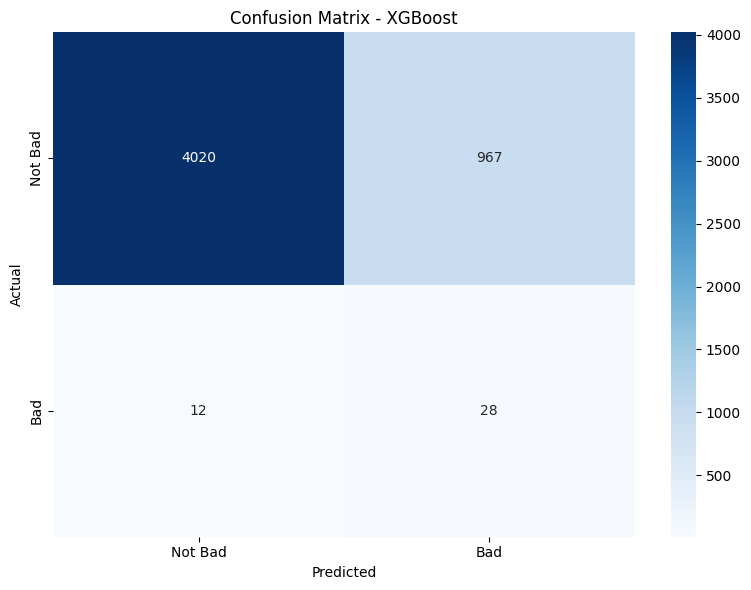


Classification Report for XGBoost Model:
              precision    recall  f1-score   support

           0       1.00      0.81      0.89      4987
           1       0.03      0.70      0.05        40

    accuracy                           0.81      5027
   macro avg       0.51      0.75      0.47      5027
weighted avg       0.99      0.81      0.88      5027


Saving trained models...

All models and related data have been saved successfully at: D:\File Gaung\Kuliah TIF UB\BCC\Intern 2025\Project\models\2nd_models\final_model.pkl


In [133]:
if __name__ == "__main__":
    # Run the main function
    trained_models, manual_thresholds, best_model_name, results, table = main()
    
    # Display summary of results
    print("\n=== MODEL TRAINING SUMMARY ===")
    print("\nModel Evaluation Results:")
    print(table)
    
    # 1. Best Model Information 
    best_model = trained_models[best_model_name]
    best_threshold = manual_thresholds[best_model_name]
    
    print(f"Best Model: {best_model_name}")
    print(f"Optimal Threshold: {best_threshold:.4f}")
    
    # 2. Visualize Results - Create a comparison chart of metrics
    # Extract metrics for visualization
    model_names = [result[0] for result in results]
    recalls = [result[5] for result in results]  # Index 5 is recall
    precisions = [result[4] for result in results]  # Index 4 is precision
    f2_scores = [result[7] for result in results]  # Index 7 is F2 score
    
    # Plot metrics comparison
    plt.figure(figsize=(12, 6))
    bar_width = 0.25
    x = np.arange(len(model_names))
    
    plt.bar(x - bar_width, recalls, width=bar_width, label='Recall', color='#3498db')
    plt.bar(x, precisions, width=bar_width, label='Precision', color='#2ecc71')
    plt.bar(x + bar_width, f2_scores, width=bar_width, label='F2 Score', color='#9b59b6')
    
    plt.xlabel('Models')
    plt.ylabel('Score')
    plt.title('Model Performance Comparison')
    plt.xticks(x, model_names, rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # 3. Display Confusion Matrix for each model
    y_test = test_original['IS_BAD']
    X_test_preprocessed = preprocessing_pipeline.transform(test_original.drop(columns=['IS_BAD']))
    
    for model_name in model_names:
        # Get the model object and its threshold
        model_object = trained_models[model_name]
        threshold = manual_thresholds[model_name]
    
        # Make predictions using the manual threshold
        y_proba = model_object.predict_proba(X_test_preprocessed)[:, 1]
        y_pred = (y_proba >= threshold)
    
        cm = confusion_matrix(y_test, y_pred)
    
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=['Not Bad', 'Bad'], 
                    yticklabels=['Not Bad', 'Bad'])
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.title(f'Confusion Matrix - {model_name}')
        plt.tight_layout()
        plt.show()
        
        # 4. Generate a classification report
        print(f"\nClassification Report for {model_name} Model:")
        print(classification_report(y_test, y_pred))
    
    # 5. Save all trained models
    print("\nSaving trained models...")
    
    # Specify save location
    save_dir = r"D:\File Gaung\Kuliah TIF UB\BCC\Intern 2025\Project\models\2nd_models"
    os.makedirs(save_dir, exist_ok=True)  # Create folder if it doesn't exist
    
    # Save all important components in one dictionary
    model_data = {
        "models": trained_models,  # All trained models
        "preprocessing_pipeline": preprocessing_pipeline,  # Preprocessing pipeline
        "thresholds": manual_thresholds,  # Manual thresholds for each model
    }
    
    # Save to .pkl file
    model_path = os.path.join(save_dir, "final_model.pkl")
    joblib.dump(model_data, model_path)
    
    print(f"\nAll models and related data have been saved successfully at: {model_path}")